# Détection Automatique de Pathologies
## Classification Binaire sur SynMedTab-800

**Objectif** : Construire et comparer plusieurs modèles de classification binaire pour prédire la présence ou l'absence d'une pathologie à partir de données cliniques tabulaires synthétiques.

**Dataset** : SynMedTab-800
- Données synthétiques représentant 800 patients
- Variables quantitatives : âge, pression artérielle, cholestérol, glycémie, IMC
- Variables catégorielles : statut tabagique, niveau d'activité, antécédents familiaux, qualité alimentation
- Cible binaire : présence (1) ou absence (0) de pathologie

**Méthodologie** : Suivre le pipeline ML complet depuis l'exploration jusqu'à l'analyse critique des résultats, en progressant du modèle simple au plus complexe.

## 1. IMPORTS ET CONFIGURATION

Pour installer les dépendances nécessaires, exécutez la cellule suivante sinon passez à la cellule suivante.

In [ ]:
%pip install -r requirements.txt

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, auc,
                             classification_report, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Tous les imports réussis")

✓ Tous les imports réussis


## 2. CHARGEMENT DES DONNÉES

In [7]:
df = pd.read_csv('SynMedTab-800.csv')

print("Aperçu du dataset:")
print(df.head())
print(f"\nDimensions: {df.shape}")
print(f"\nTypes de données:")
print(df.dtypes)
print(f"\nValeurs manquantes avant transformation:")
print(df.isnull().sum())

Aperçu du dataset:
   patient_id   age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
0           1  68.7                125.6             193.9           NaN   
1           2  64.3                132.5             173.4          75.2   
2           3  51.1                118.3             213.3          86.4   
3           4   NaN                146.7             193.7          82.9   
4           5  47.5                144.3             182.6         182.6   

    bmi smoking_status physical_activity family_history diet_quality disease  
0  29.5          Never          Moderate             No    Excellent      No  
1  24.5          Never          Moderate             No         Fair      No  
2  26.2         Former              High            NaN         Good      No  
3  27.8          Never               NaN             No          NaN      No  
4  31.6          Never               Low            Yes         Poor     Yes  

Dimensions: (800, 11)

Types de données:
patient_

---
## 3. EXPLORATION ET ANALYSE EXPLORATOIRE (EDA)

### 3.1 Distribution de la variable cible

Distribution de la variable cible (disease):
disease
No     614
Yes    186
Name: count, dtype: int64

Proportion:
disease
No     0.7675
Yes    0.2325
Name: proportion, dtype: float64


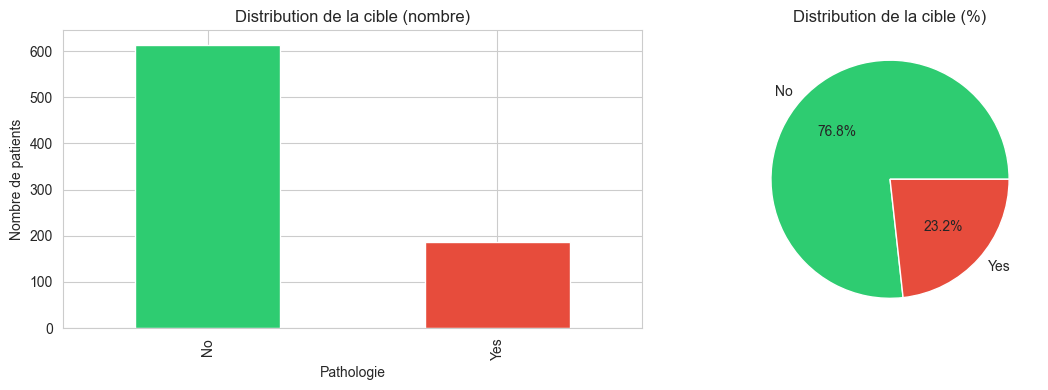


Cible convertie: No=0, Yes=1
Imbalancement des classes: 76.8%


In [8]:
target_col = 'disease'

print(f"Distribution de la variable cible ({target_col}):")
print(df[target_col].value_counts())
print(f"\nProportion:")
print(df[target_col].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Distribution de la cible (nombre)')
ax[0].set_ylabel('Nombre de patients')
ax[0].set_xlabel('Pathologie')

df[target_col].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                                   colors=['#2ecc71', '#e74c3c'])
ax[1].set_title('Distribution de la cible (%)')
plt.tight_layout()
plt.show()

# Convertir 'No'/'Yes' en 0/1
df[target_col] = (df[target_col] == 'Yes').astype(int)
print(f"\nCible convertie: No=0, Yes=1")
imbalance = abs(100 - df[target_col].value_counts(normalize=True)[1]*100)
print(f"Imbalancement des classes: {imbalance:.1f}%")

### 3.2 Identification des variables

In [9]:
numerical_cols = ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']
categorical_cols = ['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

print(f"Variables quantitatives ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nVariables catégorielles ({len(categorical_cols)}):")
print(categorical_cols)

print(f"\nStatistiques descriptives des variables quantitatives:")
print(df[numerical_cols].describe())

Variables quantitatives (5):
['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']

Variables catégorielles (4):
['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

Statistiques descriptives des variables quantitatives:
              age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
count  716.000000           730.000000        721.000000    704.000000   
mean    51.353911           126.327397        209.344105    107.010085   
std     13.256483            19.297168         37.638613     29.352447   
min     18.000000            78.800000        105.400000     50.000000   
25%     43.075000           113.600000        185.900000     88.300000   
50%     51.600000           124.800000        206.000000    101.250000   
75%     60.050000           137.850000        232.000000    119.850000   
max     89.700000           199.400000        335.800000    243.100000   

              bmi  
count  733.000000  
mean    26.539291  
std      4

### 3.3 Analyse des anomalies et valeurs manquantes

Zéros par colonne numérique:

Valeurs manquantes par colonne:
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64


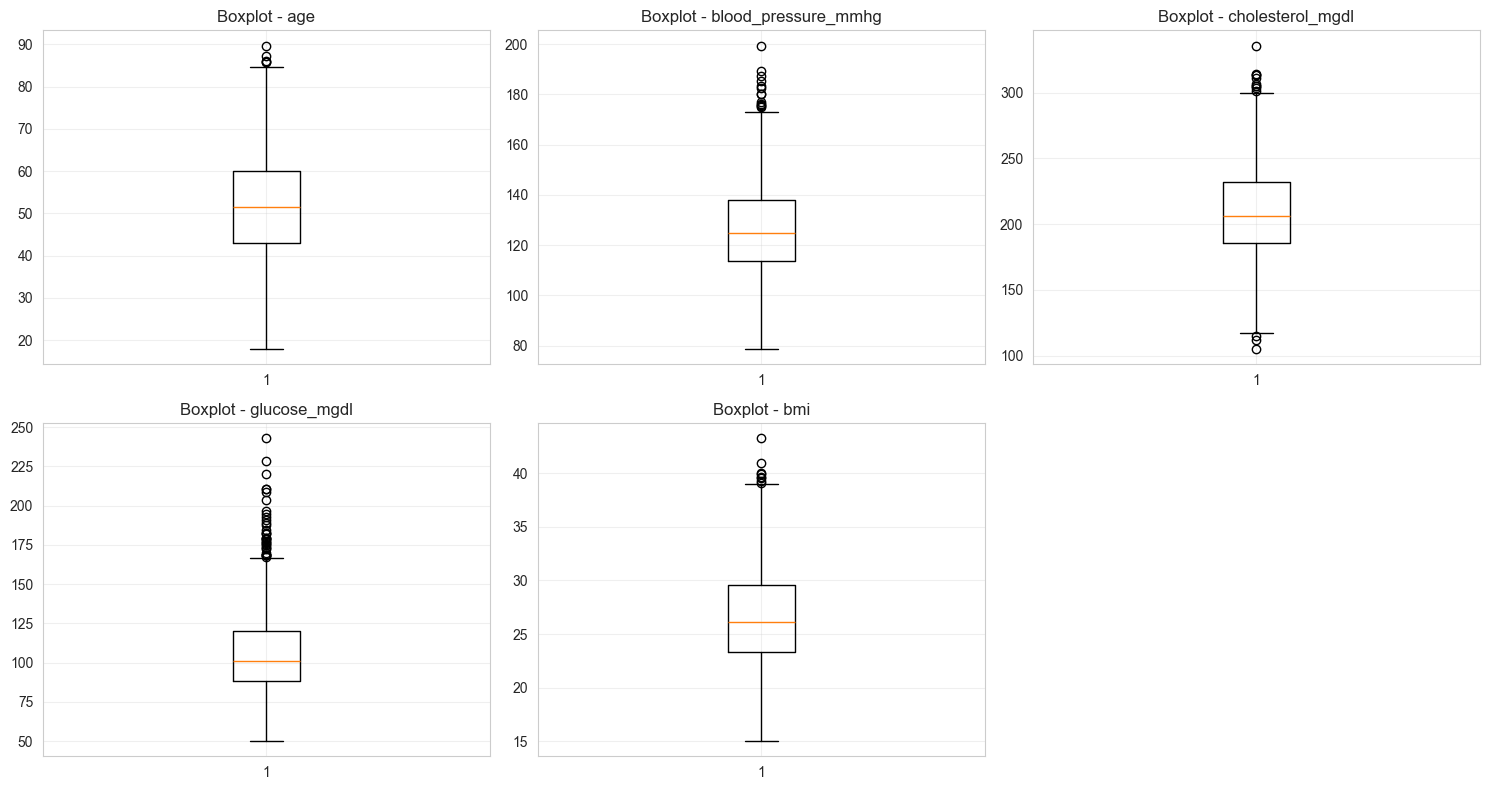


✓ Anomalies détectées: zéros biologiquement impossibles, valeurs manquantes


In [10]:
print("Zéros par colonne numérique:")
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zéros ({zero_count/len(df)*100:.1f}%)")

print("\nValeurs manquantes par colonne:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Visualisation des anomalies
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot - {col}')
    axes[idx].grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

print("\n✓ Anomalies détectées: zéros biologiquement impossibles, valeurs manquantes")

### 3.4 Corrélations avec la cible

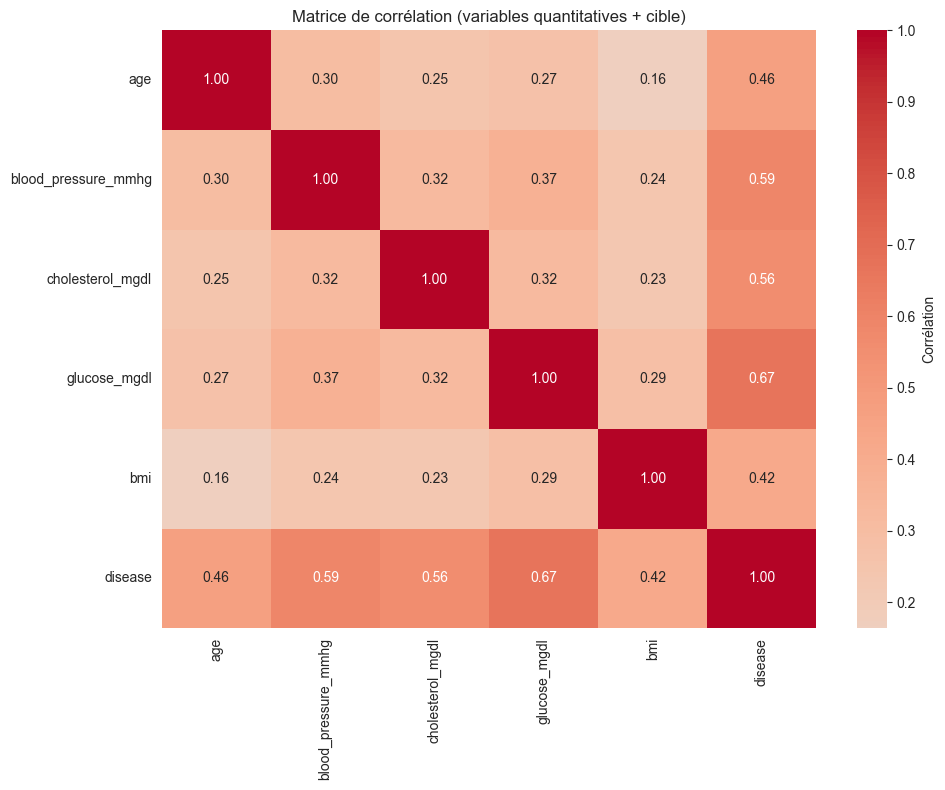


Corrélations avec la cible (disease):
disease                1.000000
glucose_mgdl           0.666476
blood_pressure_mmhg    0.586087
cholesterol_mgdl       0.556106
age                    0.463024
bmi                    0.419289
Name: disease, dtype: float64


In [11]:
data_for_corr = df[numerical_cols + [target_col]].copy()
corr_matrix = data_for_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation (variables quantitatives + cible)')
plt.tight_layout()
plt.show()

print(f"\nCorrélations avec la cible ({target_col}):")
target_corr = corr_matrix[target_col].sort_values(ascending=False)
print(target_corr)

---
## 4. PRÉPARATION ET NETTOYAGE DES DONNÉES

### 4.1 Séparation features / target

In [12]:
X = df.drop(columns=[target_col, 'patient_id'])
y = df[target_col]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nColonnes de X: {X.columns.tolist()}")

X shape: (800, 9)
y shape: (800,)

Colonnes de X: ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi', 'smoking_status', 'physical_activity', 'family_history', 'diet_quality']


### 4.2 Gestion des valeurs manquantes et anomalies

In [13]:
X_clean = X.copy()

print("Remplacement des zéros biologiquement impossibles par NaN:")
X_clean.loc[X_clean['blood_pressure_mmhg'] == 0, 'blood_pressure_mmhg'] = np.nan
print(f"  ✓ blood_pressure_mmhg")
X_clean.loc[X_clean['cholesterol_mgdl'] == 0, 'cholesterol_mgdl'] = np.nan
print(f"  ✓ cholesterol_mgdl")
X_clean.loc[X_clean['glucose_mgdl'] == 0, 'glucose_mgdl'] = np.nan
print(f"  ✓ glucose_mgdl")
X_clean.loc[X_clean['bmi'] == 0, 'bmi'] = np.nan
print(f"  ✓ bmi")

print("\nValeurs manquantes après remplacement des zéros:")
print(X_clean.isnull().sum())

# Imputation avec la médiane pour variables numériques
imputer_num = SimpleImputer(strategy='median')
X_clean[numerical_cols] = imputer_num.fit_transform(X_clean[numerical_cols])

print("\nAprès imputation (médiane):")
print(X_clean.isnull().sum())
print("✓ Valeurs manquantes traitées")

Remplacement des zéros biologiquement impossibles par NaN:
  ✓ blood_pressure_mmhg
  ✓ cholesterol_mgdl
  ✓ glucose_mgdl
  ✓ bmi

Valeurs manquantes après remplacement des zéros:
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64

Après imputation (médiane):
age                     0
blood_pressure_mmhg     0
cholesterol_mgdl        0
glucose_mgdl            0
bmi                     0
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64
✓ Valeurs manquantes traitées


### 4.3 Train / Test Split (AVANT normalisation)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, 
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nDistribution train:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribution test:")
print(y_test.value_counts(normalize=True))
print("✓ Stratification conservée")

X_train: (640, 9)
X_test: (160, 9)

Distribution train:
disease
0    0.767188
1    0.232813
Name: proportion, dtype: float64

Distribution test:
disease
0    0.76875
1    0.23125
Name: proportion, dtype: float64
✓ Stratification conservée


### 4.4 Prétraitement : Normalisation + Encodage

In [15]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"X_test_transformed shape: {X_test_transformed.shape}")
print("✓ Normalisation et encodage complétés")

X_train_transformed shape: (640, 17)
X_test_transformed shape: (160, 17)
✓ Normalisation et encodage complétés


---
## 5. MODÉLISATION - ENTRAÎNEMENT ET ÉVALUATION

### 5.1 Fonction d'évaluation

In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]
    
    train_accuracy = (y_train_pred == y_train).mean()
    test_accuracy = (y_test_pred == y_test).mean()
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc_roc = roc_auc_score(y_test, y_test_pred_proba)
    
    print(f"\n{'='*60}")
    print(f"MODÈLE: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy train: {train_accuracy:.4f}")
    print(f"Accuracy test:  {test_accuracy:.4f}")
    print(f"Surapprentissage: {abs(train_accuracy - test_accuracy):.4f}")
    print(f"\nMatrice de confusion (test):")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    print(f"  TP: {cm[1,1]}, TN: {cm[0,0]}, FP: {cm[0,1]}, FN: {cm[1,0]}")
    print(f"\nPrécision: {precision:.4f}")
    print(f"Rappel:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    
    return {
        'Model': model_name,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'AUC_ROC': auc_roc,
        'Overfit_Gap': abs(train_accuracy - test_accuracy),
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba,
        'model': model
    }

### 5.2 Modèle 1 : Régression Logistique

In [17]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_transformed, y_train)

results_lr = evaluate_model(model_lr, X_train_transformed, X_test_transformed, 
                              y_train, y_test, "Régression Logistique")


MODÈLE: Régression Logistique
Accuracy train: 0.9781
Accuracy test:  0.9500
Surapprentissage: 0.0281

Matrice de confusion (test):
[[117   6]
 [  2  35]]
  TP: 35, TN: 117, FP: 6, FN: 2

Précision: 0.8537
Rappel:    0.9459
F1-score:  0.8974
AUC-ROC:   0.9800


### 5.3 Modèle 2 : Arbre de Décision

In [18]:
model_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model_dt.fit(X_train_transformed, y_train)

results_dt = evaluate_model(model_dt, X_train_transformed, X_test_transformed,
                             y_train, y_test, "Arbre de Décision")

print(f"\nImportance des features (Top 10):")
feature_importance = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_dt.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance)


MODÈLE: Arbre de Décision
Accuracy train: 0.9563
Accuracy test:  0.8875
Surapprentissage: 0.0688

Matrice de confusion (test):
[[114   9]
 [  9  28]]
  TP: 28, TN: 114, FP: 9, FN: 9

Précision: 0.7568
Rappel:    0.7568
F1-score:  0.7568
AUC-ROC:   0.9107

Importance des features (Top 10):
    feature  importance
3         3    0.571921
2         2    0.183988
1         1    0.178896
0         0    0.040222
15       15    0.011478
6         6    0.008723
4         4    0.003068
8         8    0.001704
5         5    0.000000
7         7    0.000000


### 5.4 Modèle 3 : Forêt Aléatoire

In [19]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
model_rf.fit(X_train_transformed, y_train)

results_rf = evaluate_model(model_rf, X_train_transformed, X_test_transformed,
                             y_train, y_test, "Forêt Aléatoire")

print(f"\nImportance des features (Top 10):")
feature_importance_rf = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance_rf)


MODÈLE: Forêt Aléatoire
Accuracy train: 0.9812
Accuracy test:  0.9125
Surapprentissage: 0.0687

Matrice de confusion (test):
[[113  10]
 [  4  33]]
  TP: 33, TN: 113, FP: 10, FN: 4

Précision: 0.7674
Rappel:    0.8919
F1-score:  0.8250
AUC-ROC:   0.9692

Importance des features (Top 10):
    feature  importance
1         1    0.274073
3         3    0.244235
2         2    0.196307
0         0    0.118267
4         4    0.079299
8         8    0.027831
11       11    0.021295
6         6    0.016209
15       15    0.005930
14       14    0.004935


---
## 6. COMPARAISON DES MODÈLES

### 6.1 Tableau comparatif

In [20]:
comparison_df = pd.DataFrame([
    results_lr,
    results_dt,
    results_rf
])

comparison_display = comparison_df[[
    'Model', 'Train_Accuracy', 'Test_Accuracy', 'Overfit_Gap',
    'Precision', 'Recall', 'F1_Score', 'AUC_ROC'
]].round(4)

print("\n" + "="*100)
print("COMPARAISON DES MODÈLES")
print("="*100)
print(comparison_display.to_string(index=False))
print("="*100)


COMPARAISON DES MODÈLES
                Model  Train_Accuracy  Test_Accuracy  Overfit_Gap  Precision  Recall  F1_Score  AUC_ROC
Régression Logistique          0.9781         0.9500       0.0281     0.8537  0.9459    0.8974   0.9800
    Arbre de Décision          0.9562         0.8875       0.0688     0.7568  0.7568    0.7568   0.9107
      Forêt Aléatoire          0.9812         0.9125       0.0687     0.7674  0.8919    0.8250   0.9692


### 6.2 Visualisation comparative

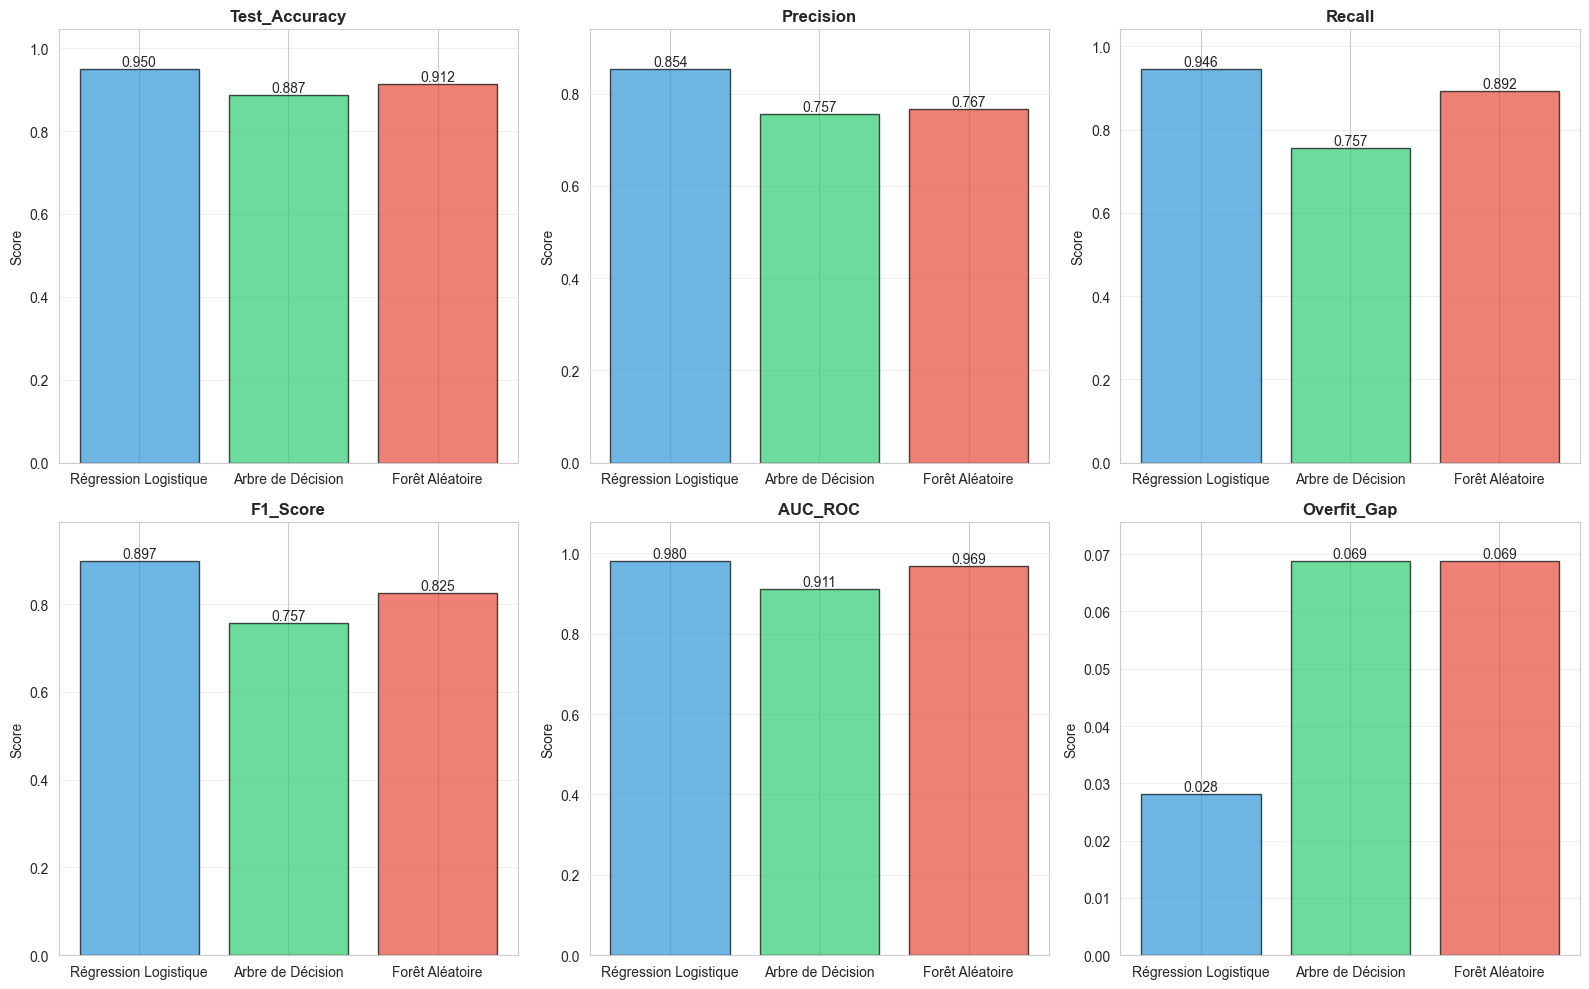

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC_ROC', 'Overfit_Gap']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    values = [comparison_df.iloc[i][metric] for i in range(len(comparison_df))]
    models = comparison_df['Model'].tolist()
    
    bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, max(values) * 1.1])
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 6.3 Courbes ROC

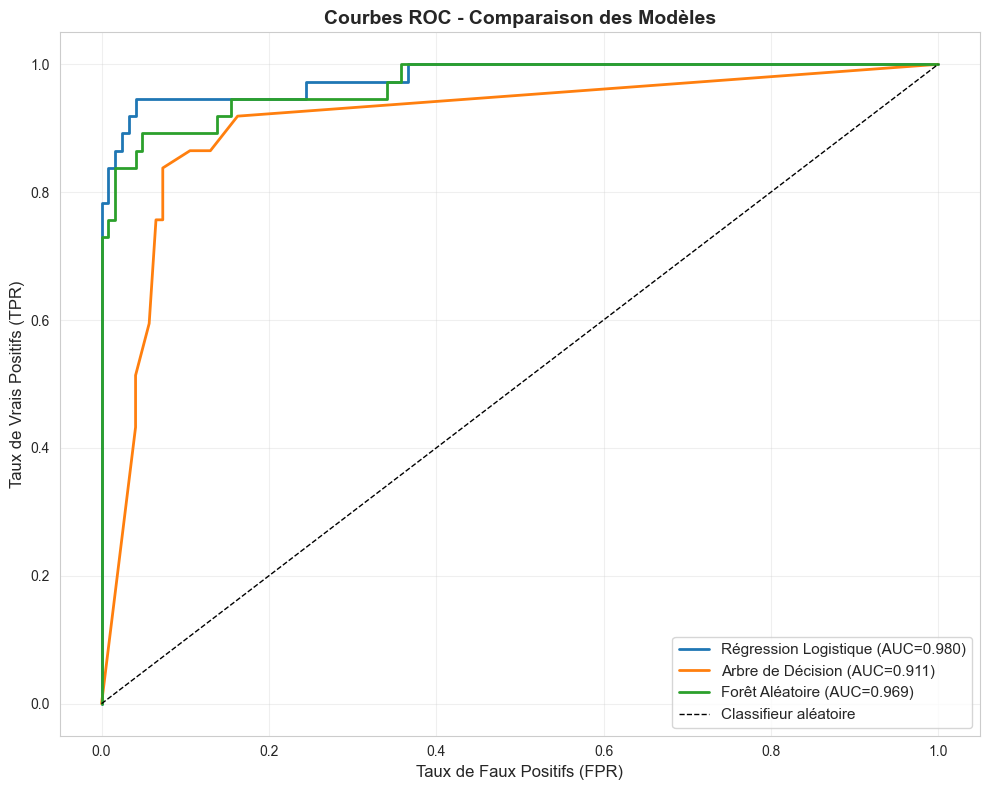

In [22]:
plt.figure(figsize=(10, 8))

y_lr_proba = model_lr.predict_proba(X_test_transformed)[:, 1]
y_dt_proba = model_dt.predict_proba(X_test_transformed)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, results_dt['y_test_pred_proba'])
fpr_rf, tpr_rf, _ = roc_curve(y_test, results_rf['y_test_pred_proba'])

plt.plot(fpr_lr, tpr_lr, label=f'Régression Logistique (AUC={results_lr["AUC_ROC"]:.3f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Arbre de Décision (AUC={results_dt["AUC_ROC"]:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Forêt Aléatoire (AUC={results_rf["AUC_ROC"]:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Classifieur aléatoire', linewidth=1)

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Matrices de confusion

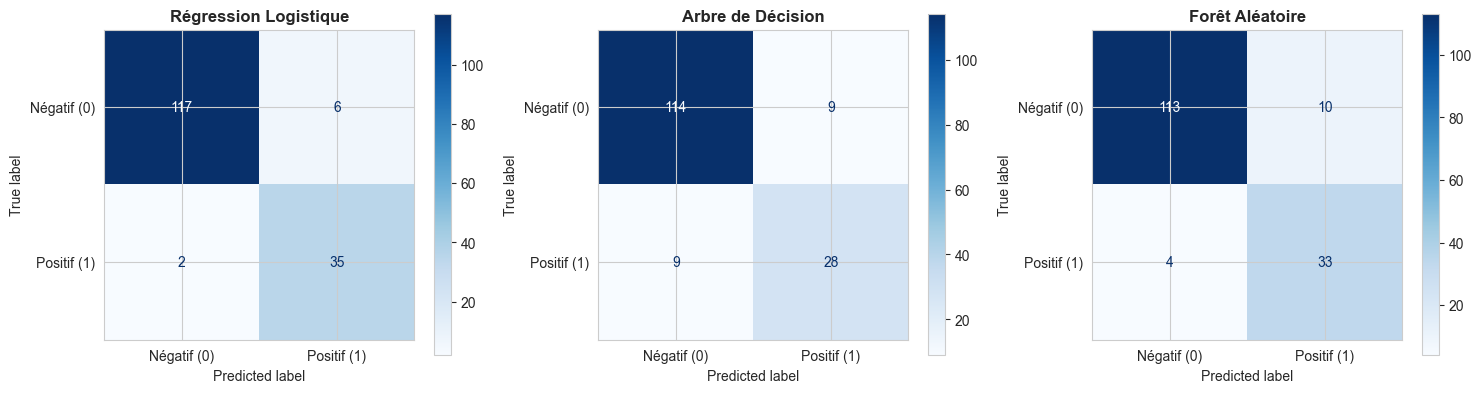

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_info = [
    (results_lr, "Régression Logistique", axes[0]),
    (results_dt, "Arbre de Décision", axes[1]),
    (results_rf, "Forêt Aléatoire", axes[2])
]

for result, name, ax in models_info:
    y_pred = result['y_test_pred']
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Négatif (0)', 'Positif (1)'])
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. ANALYSE CRITIQUE ET RÉSULTATS

### 7.1 Analyse complète

In [24]:
print("ANALYSE CLINIQUE ET D'INTERPRÉTATION")
print("="*80)

print("\n1. DÉSÉQUILIBRE DES CLASSES:")
class_0_pct = (y==0).sum()/len(y)*100
class_1_pct = (y==1).sum()/len(y)*100
print(f"   - Absence de pathologie (0): {class_0_pct:.1f}%")
print(f"   - Présence de pathologie (1): {class_1_pct:.1f}%")
print(f"   - Imbalancement: {abs(class_0_pct - class_1_pct):.1f}%")
if abs(class_0_pct - class_1_pct) > 20:
    print(f"   ⚠️  DÉSÉQUILIBRE SIGNIFICATIF - F1-score plus pertinent qu'Accuracy")

print("\n2. MEILLEUR MODÈLE:")
best_idx = comparison_df['F1_Score'].idxmax()
best_model_name = comparison_df.iloc[best_idx]['Model']
print(f"   {best_model_name}")

print("\n3. SURAPPRENTISSAGE:")
for idx, row in comparison_df.iterrows():
    gap = row['Overfit_Gap']
    status = "⚠️  ÉLEVÉ" if gap > 0.1 else "✓ Acceptable"
    print(f"   {row['Model']}: {gap:.4f} {status}")

print("\n" + "="*80)

ANALYSE CLINIQUE ET D'INTERPRÉTATION

1. DÉSÉQUILIBRE DES CLASSES:
   - Absence de pathologie (0): 76.8%
   - Présence de pathologie (1): 23.2%
   - Imbalancement: 53.5%
   ⚠️  DÉSÉQUILIBRE SIGNIFICATIF - F1-score plus pertinent qu'Accuracy

2. MEILLEUR MODÈLE:
   Régression Logistique

3. SURAPPRENTISSAGE:
   Régression Logistique: 0.0281 ✓ Acceptable
   Arbre de Décision: 0.0688 ✓ Acceptable
   Forêt Aléatoire: 0.0687 ✓ Acceptable



### 7.2 Rapport du meilleur modèle

In [25]:
best_idx = comparison_df['F1_Score'].idxmax()
best_result = comparison_df.iloc[best_idx]
best_model_name = best_result['Model']

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print("="*80)

y_best_pred = [results_lr, results_dt, results_rf][best_idx]['y_test_pred']
print("\nRAPPORT DE CLASSIFICATION:")
print(classification_report(y_test, y_best_pred, 
                           target_names=['Pas de pathologie', 'Pathologie présente']))

print("ANALYSE À COMPLÉTER:")
print("- Justifiez pourquoi ce modèle est le meilleur")
print("- Analysez les forces et faiblesses")
print("- Commentez les implications cliniques")


🏆 MEILLEUR MODÈLE: Régression Logistique

RAPPORT DE CLASSIFICATION:
                     precision    recall  f1-score   support

  Pas de pathologie       0.98      0.95      0.97       123
Pathologie présente       0.85      0.95      0.90        37

           accuracy                           0.95       160
          macro avg       0.92      0.95      0.93       160
       weighted avg       0.95      0.95      0.95       160

ANALYSE À COMPLÉTER:
- Justifiez pourquoi ce modèle est le meilleur
- Analysez les forces et faiblesses
- Commentez les implications cliniques


---
## 8. CONCLUSIONS

### Résumé et recommandations

[À COMPLÉTER]

### Limitations

[À COMPLÉTER]

### Améliorations futures

[À COMPLÉTER]